In [1]:
import sys
sys.path.append('/host/d/Github/')
import SimpleITK as sitk
import glob
import os
import glob
import lpips
import torch
import numpy as np
import pandas as pd
import nibabel as nb
from skimage.metrics import structural_similarity
import matplotlib.pyplot as plt


import Diffusion_denoising_thin_slice.functions_collection as ff
import Diffusion_denoising_thin_slice.Build_lists.Build_list as Build_list

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
build_sheet =  Build_list.Build(os.path.join('/host/e/D/Data/low_dose_CT/Patient_lists/mayo_low_dose_CT_gaussian_simulation_highnoise_v2.xlsx'))
batch_list, patient_id_list, random_num_list,noise_file_all_list, noise_file_odd_list, noise_file_even_list, ground_truth_file_list, slice_num_list = build_sheet.__build__(batch_list = ['test']) 
n = ff.get_X_numbers_in_interval(total_number = patient_id_list.shape[0],start_number = 0,end_number = 1, interval = 1)

In [11]:
def calc_mae_with_ref_window(img, ref, vmin, vmax):
    maes = []
    for slice_num in range(0, img.shape[-1]):
        slice_img = img[:,:,slice_num]
        slice_ref = ref[:,:,slice_num]
        mask = np.where((slice_ref >= vmin) & (slice_ref <= vmax), 1, 0)
        mae = np.sum(np.abs(slice_img - slice_ref) * mask) / np.sum(mask)
        maes.append(mae)

    return np.mean(maes), np.std(maes)

def calc_ssim_with_ref_window(img, ref, vmin, vmax):

    ssims = []
    for slice_num in range(0, img.shape[-1]):
        slice_img = img[:,:,slice_num]
        slice_ref = ref[:,:,slice_num]
        mask = np.where((slice_ref >= vmin) & (slice_ref <= vmax), 1, 0)
        _, ssim_map = structural_similarity(slice_img, slice_ref, data_range=vmax - vmin, full=True)
        ssim = np.sum(ssim_map * mask) / np.sum(mask)
        ssims.append(ssim)

    return np.mean(ssims), np.std(ssims)

def calc_lpips(imgs1, imgs2, vmin, vmax):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    loss_fn = lpips.LPIPS().to(device)
    
    lpipss = []
    for slice_num in range(0, imgs1.shape[-1]):
        slice1 = imgs1[:,:,slice_num]
        slice2 = imgs2[:,:,slice_num]

        slice1 = np.clip(slice1, vmin, vmax).astype(np.float32)
        slice2 = np.clip(slice2, vmin, vmax).astype(np.float32)

        slice1 = (slice1 - vmin) / (vmax - vmin) * 2 - 1
        slice2 = (slice2 - vmin) / (vmax - vmin) * 2 - 1

        slice1 = np.stack([slice1, slice1, slice1], axis=-1)
        slice2 = np.stack([slice2, slice2, slice2], axis=-1)
        # print('after stack, slice1 shape:', slice1.shape, ' slice2 shape:', slice2.shape)

        slice1 = np.transpose(slice1, (2, 0, 1))[np.newaxis, ...]
        slice2 = np.transpose(slice2, (2, 0, 1))[np.newaxis, ...]
        # print('after transpose, slice1 shape:', slice1.shape, ' slice2 shape:', slice2.shape)

        slice1 = torch.from_numpy(slice1).to(device)
        slice2 = torch.from_numpy(slice2).to(device)

        lpips_val = loss_fn(slice1, slice2)
        lpipss.append(lpips_val.item())

      

    return np.mean(lpipss), np.std(lpipss)

# get metrics curve according to number of inferences

In [16]:
num_inferences = [1, 2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]

mae_list = []
ssim_list = []
lpips_list = []

for i in range(0, len(num_inferences)):
    n_infer = num_inferences[i]
    print(f'Number of inferences: {n_infer}')

    mae_for_this_infer = []
    ssim_for_this_infer = []
    lpips_for_this_infer = []

    for j in range(0, len(n)):

        patient_id = patient_id_list[n[j]]
        random_n = random_num_list[n[j]]
        print(patient_id,  random_n)

        # reference image
        gt_file = os.path.join('/host/e/D/Data/low_dose_CT/nii_imgs', patient_id,  'img_sliced.nii.gz')
        gt_img = nb.load(gt_file).get_fdata()

        # # our method 
        # if n_infer != 1:
        unsupervised_beta0_avg_file = os.path.join('/host/d/projects/denoising/models/unsupervised_gaussian_mayo_highnoise/pred_images_input_both', patient_id,'random_'+str(random_n), 'epoch165avg/pred_img_scans' + str(n_infer) + '.nii.gz')
        unsupervised_beta0_avg_img = nb.load(unsupervised_beta0_avg_file).get_fdata()
        # else:
        #     unsupervised_beta0_avg_file = os.path.join('/host/d/projects/denoising/models/unsupervised_gaussian_2/pred_images_input_both', patient_id,'random_'+str(random_n), 'epoch105_1/pred_img.nii.gz')
        #     unsupervised_beta0_avg_img = nb.load(unsupervised_beta0_avg_file).get_fdata()

        vmin = -160
        vmax = 240
        mae_case,_= calc_mae_with_ref_window(unsupervised_beta0_avg_img, gt_img, vmin, vmax)
        ssim_case, _ = calc_ssim_with_ref_window(unsupervised_beta0_avg_img, gt_img, vmin, vmax)
        lpips_case, _ = calc_lpips(unsupervised_beta0_avg_img, gt_img, vmin, vmax)
        print(f'MAE: {mae_case}, SSIM: {ssim_case}', f'LPIPS: {lpips_case}')

        mae_for_this_infer.append(mae_case)
        ssim_for_this_infer.append(ssim_case)
        lpips_for_this_infer.append(lpips_case)
    print('mae for this inference:', mae_for_this_infer, 'ssim for this inference:', ssim_for_this_infer, 'lpips for this inference:', lpips_for_this_infer)

    mae_list.append(np.mean(mae_for_this_infer))
    ssim_list.append(np.mean(ssim_for_this_infer))
    lpips_list.append(np.mean(lpips_for_this_infer))

# save it into a dataframe
df = pd.DataFrame({'num_inferences': num_inferences, 'MAE': mae_list, 'SSIM': ssim_list, 'LPIPS': lpips_list})
df.to_excel('/host/d/projects/denoising/results/multiple_inference_analysis_mayo_highnoise.xlsx', index=False)


Number of inferences: 1
L310 0
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.10/dist-packages/lpips/weights/v0.1/alex.pth
MAE: 19.26214854456238, SSIM: 0.5375211547728022 LPIPS: 0.09838879026472569
L192 0
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.10/dist-packages/lpips/weights/v0.1/alex.pth
MAE: 17.154486607203314, SSIM: 0.6138646420509263 LPIPS: 0.055616936460137364
L291 0
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


...

Loading model from: /usr/local/lib/python3.10/dist-packages/lpips/weights/v0.1/alex.pth
MAE: 13.617504488553385, SSIM: 0.6776670960081604 LPIPS: 0.051845706924796106
L192 0
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.10/dist-packages/lpips/weights/v0.1/alex.pth
MAE: 11.795792419234408, SSIM: 0.7471099020358575 LPIPS: 0.03167424868792296
L291 0
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.10/dist-packages/lpips/weights/v0.1/alex.pth
MAE: 16.655003473417775, SSIM: 0.6647924325496338 LPIPS: 0.056697876527905464
mae for this inference: [13.617504488553385, 11.795792419234408, 16.655003473417775] ssim for this inference: [0.6776670960081604, 0.7471099020358575, 0.6647924325496338] lpips for this inference: [0.051845706924796106, 0.03167424868792296, 0.056697876527905464]


In [34]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [35]:
## load data
data = pd.read_excel('/host/d/projects/denoising/results/multiple_inference_analysis_mayo_highnoise.xlsx')
num_inferences = data['num_inferences'].values
mae_list = data['MAE'].values
ssim_list = data['SSIM'].values

### mae

In [36]:
x = np.asarray(num_inferences)
y = np.asarray(mae_list)


def log_func(x, a, b):
    return a * np.log(x) + b

def power_func(x, a, b, c):
    return a * x**(-b) + c

def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# 曲线拟合（增加maxfev确保收敛，与原代码一致）
popt_log, _ = curve_fit(log_func, x, y)
popt_pow, _ = curve_fit(power_func, x, y, maxfev=10000)
popt_exp, _ = curve_fit(exp_func, x, y, maxfev=10000)

# 生成拟合曲线的x/y值（更密集的x_fit确保曲线平滑）
x_fit = np.linspace(1, 20, 200)
y_log = log_func(x_fit, *popt_log)
y_pow = power_func(x_fit, *popt_pow)
y_exp = exp_func(x_fit, *popt_exp)

# 计算R²（与原代码一致）
r2_exp = r2_score(y, exp_func(x, *popt_exp))
r2_log = r2_score(y, log_func(x, *popt_log))
r2_pow = r2_score(y, power_func(x, *popt_pow))

# 打印 power-law 公式与参数
a_pow, b_pow, c_pow = popt_pow
print(f'Power-law parameters: a={a_pow:.8f}, b={b_pow:.8f}, c={c_pow:.8f}')
print(f'Power-law formula: y = {a_pow:.8f} * x^(-{b_pow:.8f}) + {c_pow:.8f}')

# 计算幂律拟合的极限值（与原代码一致）
y_limit_pow = power_func(20, *popt_pow)
print('for power law, the limit of y when x is very large is:', y_limit_pow)

Power-law parameters: a=6.37387953, b=0.85974839, c=13.52405540
Power-law formula: y = 6.37387953 * x^(-0.85974839) + 13.52405540
for power law, the limit of y when x is very large is: 14.009171183639504


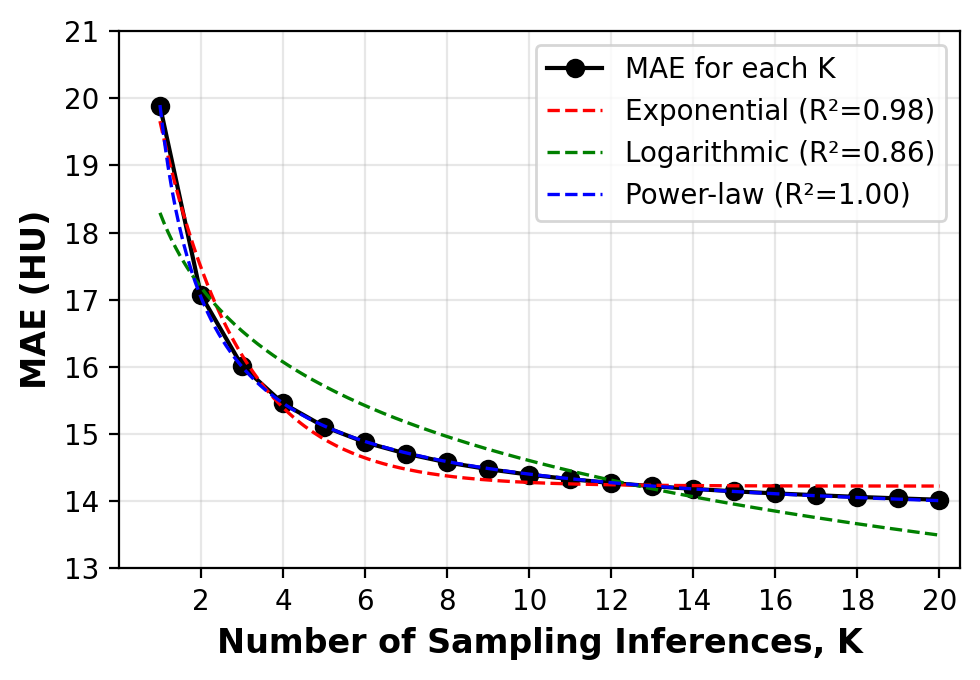

In [39]:
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)  # 用ax对象更易控制坐标轴

# 1. 绘制原始数据点与拟合曲线（保留原样式）
ax.plot(x, y, 'ko-', label='MAE for each K', linewidth=1.5, markersize=6)  # 黑色圆点+实线
ax.plot(x_fit, y_exp, 'r--', label=f'Exponential (R²={r2_exp:.2f})', linewidth=1.2)  # 红色虚线
ax.plot(x_fit, y_log, 'g--', label=f'Logarithmic (R²={r2_log:.2f})', linewidth=1.2)  # 绿色虚线
ax.plot(x_fit, y_pow, 'b--', label=f'Power-law (R²={r2_pow:.2f})', linewidth=1.2)  # 蓝色虚线

# 2. 绘制FBP数据点（灰色圆点，K=1右侧，x=1.5避免重叠）
# fbp_mae = 16.7
# ax.plot(1.5, fbp_mae, 'o', color='red', markersize=6, label=f'FBP (MAE={fbp_mae} HU)')

# 3. 调整x轴：起点为0，刻度显示2,4,...,20（不显示0和1）
ax.set_xlim(0, 20.5)
ax.set_xticks(np.arange(2, 21, 2))
ax.set_xlabel('Number of Sampling Inferences, K', fontsize=12, fontweight='bold')

# 4. 调整y轴：根据数据和拟合曲线自适应，避免截断
y_all = np.concatenate([y, y_log, y_pow, y_exp])
y_min = float(np.min(y_all))
y_max = float(np.max(y_all))
y_margin = max(0.3, 0.05 * (y_max - y_min))
ax.set_ylim(y_min - y_margin, y_max + y_margin)

y_tick_start = np.floor(y_min - y_margin)
y_tick_end = np.ceil(y_max + y_margin)
ax.set_yticks(np.arange(y_tick_start, y_tick_end + 0.1, 1.0))
ax.set_ylabel('MAE (HU)', fontsize=12, fontweight='bold')

# 5. 保留网格与图例（原样式优化）
ax.grid(True, alpha=0.3, linestyle='-')  # 网格线透明度降低，更清晰
ax.legend(fontsize=10, frameon=True, loc='upper right')  # 图例位置右上，带边框


# -------------------------- 4. 保存/显示图片 --------------------------
plt.tight_layout()  # 避免标签截断
# plt.savefig('mae_fitting_with_fbp.png', dpi=300, bbox_inches='tight')
# plt.show()  # 调试时取消注释
plt.savefig('/host/d/projects/denoising/results/mae_K_fitting_mayo.pdf', dpi=300, bbox_inches='tight')

### SSIM

SSIM power-law parameters: a=-0.15103847, b=0.75409056, c=0.71293970
SSIM power-law formula: y = -0.15103847 * x^(-0.75409056) + 0.71293970


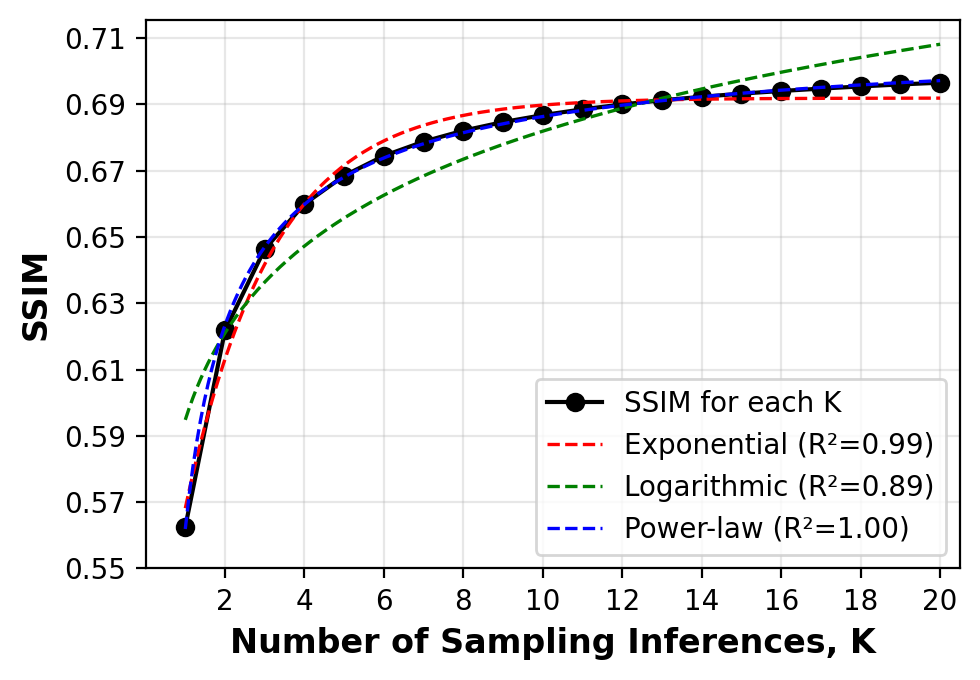

In [32]:
y = np.asarray(ssim_list)  # y轴为SSIM


# -------------------------- 2. 定义拟合函数与曲线拟合（逻辑不变） --------------------------
def log_func(x, a, b):
    return a * np.log(x) + b

def power_func(x, a, b, c):
    return a * x**(-b) + c

def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

# 曲线拟合（SSIM是上升趋势，拟合参数会自动适配）
popt_log, _ = curve_fit(log_func, x, y)
popt_pow, _ = curve_fit(power_func, x, y, maxfev=10000)
popt_exp, _ = curve_fit(exp_func, x, y, maxfev=10000)

# 生成拟合曲线
x_fit = np.linspace(1, 20, 200)
y_log = log_func(x_fit, *popt_log)
y_pow = power_func(x_fit, *popt_pow)
y_exp = exp_func(x_fit, *popt_exp)

# 计算R²
r2_exp = r2_score(y, exp_func(x, *popt_exp))
r2_log = r2_score(y, log_func(x, *popt_log))
r2_pow = r2_score(y, power_func(x, *popt_pow))

# 打印 power-law 公式与参数
a_pow, b_pow, c_pow = popt_pow
print(f'SSIM power-law parameters: a={a_pow:.8f}, b={b_pow:.8f}, c={c_pow:.8f}')
print(f'SSIM power-law formula: y = {a_pow:.8f} * x^(-{b_pow:.8f}) + {c_pow:.8f}')

# -------------------------- 3. 绘图配置（SSIM axis自适应） --------------------------
fig, ax = plt.subplots(figsize=(5,3.5), dpi=200)

# 1. 绘制原始数据与拟合曲线
ax.plot(x, y, 'ko-', label='SSIM for each K', linewidth=1.5, markersize=6)
ax.plot(x_fit, y_exp, 'r--', label=f'Exponential (R²={r2_exp:.2f})', linewidth=1.2)
ax.plot(x_fit, y_log, 'g--', label=f'Logarithmic (R²={r2_log:.2f})', linewidth=1.2)
ax.plot(x_fit, y_pow, 'b--', label=f'Power-law (R²={r2_pow:.2f})', linewidth=1.2)

# 2. 绘制FBP的SSIM数据点（可选）
# fbp_ssim = 0.744
# ax.plot(1.5, fbp_ssim, 'o', color='gray', markersize=6, label=f'FBP (SSIM={fbp_ssim})')

# 3. x轴：起点为0，刻度显示2,4,...,20（不显示0和1）
ax.set_xlim(0, 20.5)
ax.set_xticks(np.arange(2, 21, 2))
ax.set_xlabel('Number of Sampling Inferences, K', fontsize=12, fontweight='bold')

# 4. y轴：根据数据与拟合曲线自动设置
y_all = np.concatenate([y, y_log, y_pow, y_exp])
y_min = float(np.min(y_all))
y_max = float(np.max(y_all))
y_margin = max(0.005, 0.05 * (y_max - y_min))
ax.set_ylim(y_min - y_margin, y_max + y_margin)

# SSIM刻度更细一些
y_tick_start = np.floor((y_min - y_margin) * 100) / 100
y_tick_end = np.ceil((y_max + y_margin) * 100) / 100
ax.set_yticks(np.arange(y_tick_start, y_tick_end + 1e-9, 0.02))
ax.set_ylabel('SSIM', fontsize=12, fontweight='bold')

# 5. 网格与图例
ax.grid(True, alpha=0.3, linestyle='-')
ax.legend(fontsize=10, frameon=True, loc='lower right')


# -------------------------- 4. 保存图片 --------------------------
plt.tight_layout()
# plt.savefig('ssim_fitting_with_fbp.png', dpi=300, bbox_inches='tight')
# plt.show()
plt.savefig('/host/d/projects/denoising/results/ssim_K_fitting_mayo.pdf', dpi=300, bbox_inches='tight')

LPIPS power-law parameters: a=0.04218738, b=1.27731581, c=0.04555194
LPIPS power-law formula: y = 0.04218738 * x^(-1.27731581) + 0.04555194


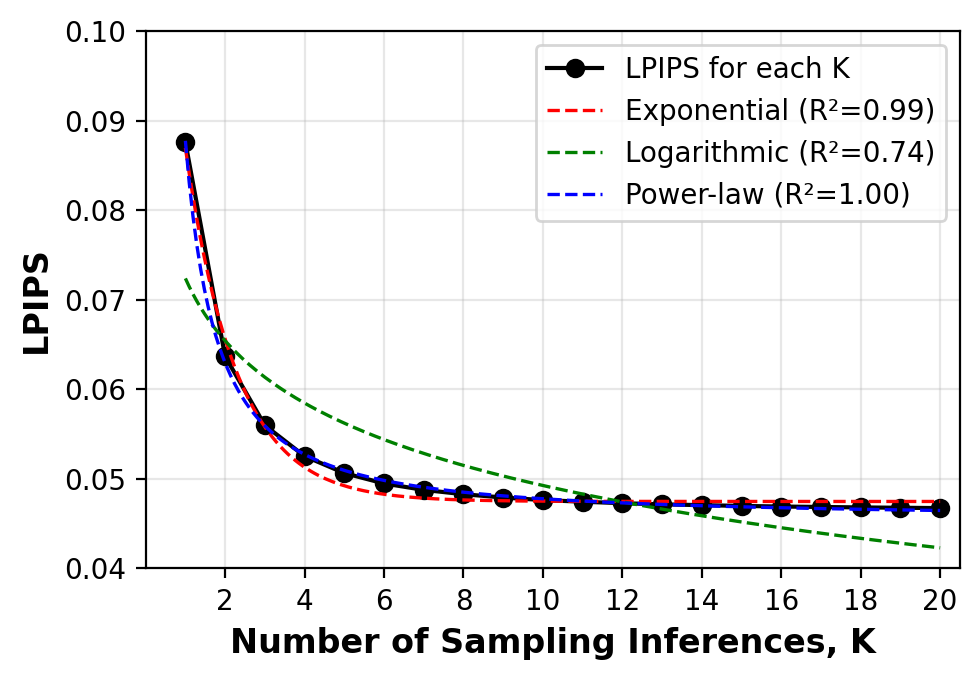

In [33]:
### LPIPS
y = np.asarray(data['LPIPS'].values)  # y轴为LPIPS

# -------------------------- 2. 定义拟合函数与曲线拟合（逻辑同MAE/SSIM） --------------------------
def log_func(x, a, b):
    return a * np.log(x) + b

def power_func(x, a, b, c):
    return a * x**(-b) + c

def exp_func(x, a, b, c):
    return a * np.exp(-b * x) + c

popt_log, _ = curve_fit(log_func, x, y)
popt_pow, _ = curve_fit(power_func, x, y, maxfev=10000)
popt_exp, _ = curve_fit(exp_func, x, y, maxfev=10000)

x_fit = np.linspace(1, 20, 200)
y_log = log_func(x_fit, *popt_log)
y_pow = power_func(x_fit, *popt_pow)
y_exp = exp_func(x_fit, *popt_exp)

r2_exp = r2_score(y, exp_func(x, *popt_exp))
r2_log = r2_score(y, log_func(x, *popt_log))
r2_pow = r2_score(y, power_func(x, *popt_pow))

# 打印 power-law 公式与参数
a_pow, b_pow, c_pow = popt_pow
print(f'LPIPS power-law parameters: a={a_pow:.8f}, b={b_pow:.8f}, c={c_pow:.8f}')
print(f'LPIPS power-law formula: y = {a_pow:.8f} * x^(-{b_pow:.8f}) + {c_pow:.8f}')

# -------------------------- 3. 绘图配置（LPIPS axis自适应） --------------------------
fig, ax = plt.subplots(figsize=(5, 3.5), dpi=200)

ax.plot(x, y, 'ko-', label='LPIPS for each K', linewidth=1.5, markersize=6)
ax.plot(x_fit, y_exp, 'r--', label=f'Exponential (R²={r2_exp:.2f})', linewidth=1.2)
ax.plot(x_fit, y_log, 'g--', label=f'Logarithmic (R²={r2_log:.2f})', linewidth=1.2)
ax.plot(x_fit, y_pow, 'b--', label=f'Power-law (R²={r2_pow:.2f})', linewidth=1.2)

# x轴：起点为0，刻度显示2,4,...,20（不显示0和1）
ax.set_xlim(0, 20.5)
ax.set_xticks(np.arange(2, 21, 2))
ax.set_xlabel('Number of Sampling Inferences, K', fontsize=12, fontweight='bold')

# y轴：根据数据与拟合曲线自动设置
y_all = np.concatenate([y, y_log, y_pow, y_exp])
y_min = float(np.min(y_all))
y_max = float(np.max(y_all))
y_margin = max(0.002, 0.05 * (y_max - y_min))
ax.set_ylim(y_min - y_margin, y_max + y_margin)

# LPIPS y轴刻度调疏
y_tick_start = np.floor((y_min - y_margin) * 100) / 100
y_tick_end = np.ceil((y_max + y_margin) * 100) / 100
ax.set_yticks(np.arange(y_tick_start, y_tick_end + 1e-9, 0.01))
ax.set_ylabel('LPIPS', fontsize=12, fontweight='bold')

ax.grid(True, alpha=0.3, linestyle='-')
ax.legend(fontsize=10, frameon=True, loc='upper right')

plt.tight_layout()
plt.savefig('/host/d/projects/denoising/results/lpips_K_fitting_mayo.pdf', dpi=300, bbox_inches='tight')